### This notebook compute "E3. Number of hectares of agricultural land, natural pastures and forested land" indicator for the 27 basins of IKI Project

Spanish: Número de hectáreas de tierras agrícolas, pasturas naturales y forestales

**Created:** 8/10/2025 by Serena Gilson (sgilson@rti.org) 

**Project #:** 0219481  

**Last modified:** 1/2/2026 by Sophia (sbakar@rti.org)

**Status:** Complete and loaded into SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure
 
**Inputs:**   
Read in SQLite database for each modeling group. The land use types were selected from table catchment_soil_values: 
'landuse_source_id = 4 AND landuse_id= 21 OR landuse_id= 22 OR landuse_id= 23 OR landuse_id= 24 OR landuse_id= 25 OR landuse_id= 31 OR landuse_id= 32 OR landuse_id= 33 OR landuse_id= 34 OR landuse_id= 41 OR landuse_id= 42 OR landuse_id= 43 OR landuse_id= 44 OR landuse_id= 45'

See landuse_types table for definition of each land use. This sqlite's land use data was populated using data from: MINAM 2015, add in source here and process for converting to our land uses
 
**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib  

**Assumptions:** Assumptions above in using our land use data for the definition of agricultural land, natural pastures, and forested land. 
 
**N/A Handling** Replace 0s with NaN for consistent handling.

**Future work:** 
 
**Notes:** 

General Methodology:  
1. Extract land use areas for each COMID from database according to the description of land use types in "Inputs" above.  
2. Sum areas of all land types for each COMID.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
# FP: C:\Users\nreynolds\Research Triangle Institute\IKI Peru Project - General\Externo\PACA_Peru\Modelacion\Indicadores
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 203 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define file paths for input data
#subbasins_shapefile = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

In [5]:
#LOOP THROUGH EACH MODELING GROUP's DATABASE AND EXTRACT AREA BY COMID FOR SELECTED LAND USES

area_byCOMID_all = pd.DataFrame(columns=['comid', 'area_ha'])

for grupo in range(1,13):
    #read in AHD database with land uses 
    #sqlite_path = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite'
    sqlite_path = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite"
    conn = sqlite3.connect(sqlite_path)

    # Read a specific table into a DataFrame
    table_name = 'catchment_soil_values'  # Replace with the table name
    df = pd.read_sql_query(f"SELECT * FROM {table_name};", conn)

    # SQL query
    condition= 'landuse_source_id = 4 AND landuse_id= 21 OR landuse_id= 22 OR landuse_id= 23 OR landuse_id= 24 OR landuse_id= 25 OR landuse_id= 31 OR landuse_id= 32 OR landuse_id= 33 OR landuse_id= 34 OR landuse_id= 41 OR landuse_id= 42 OR landuse_id= 43 OR landuse_id= 44 OR landuse_id= 45'
    query = f"SELECT comid, landuse_id, landuse_source_id, area FROM catchment_soil_values WHERE {condition};"
    result = pd.read_sql_query(query, conn)
    #convert meters squared to hectares
    result['area_ha'] = result['area'] / 10000  # Convert from m² to ha

    #sum all areas for each COMID
    area_byCOMID = result.groupby('comid', as_index=False).agg({'area_ha': 'sum', 'landuse_id': 'first', 'landuse_source_id': 'first'})
    #drop the landuse_id and landuse_source_id columns
    area_byCOMID = area_byCOMID.drop(columns=['landuse_id', 'landuse_source_id'])

    # append area_byCOMID to a new DataFrame
    area_byCOMID_all = pd.concat([area_byCOMID_all, area_byCOMID], ignore_index=True)
  
    # Close the database connection
    conn.close()
    
#area_byCOMID_all.to_csv(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Exposicion/E3_Number of hectares of agricultural land, natural pastures and forested land/E3_Area_byCOMID.csv', index=False)


C:\Users\sbakar\AppData\Local\Temp\ipykernel_572\1032020028.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  area_byCOMID_all = pd.concat([area_byCOMID_all, area_byCOMID], ignore_index=True)


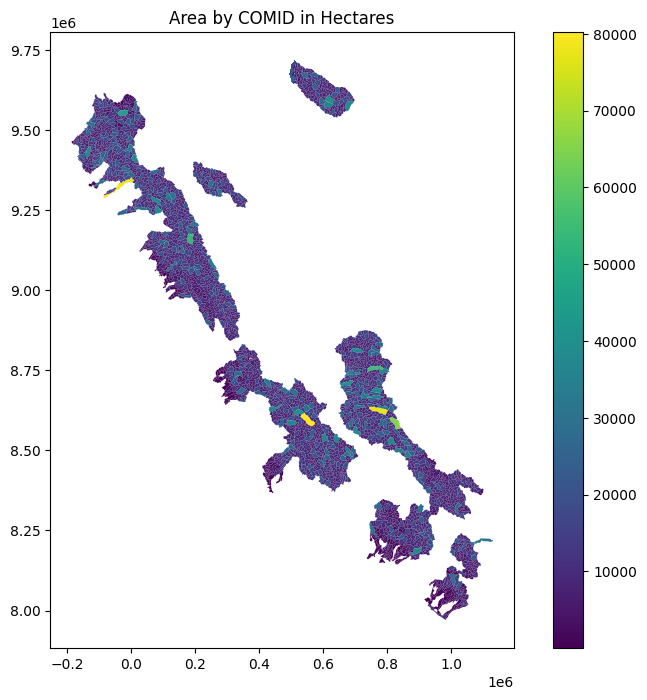

In [6]:
#MERGE BACK TO SUBBASINS GDF and PLOT

#merge area_byCOMID_all with subbasins_gdf and plot
subbasins_gdf = subbasins_gdf.merge(area_byCOMID_all, left_on='COMID', right_on='comid', how='left')
subbasins_gdf.loc[subbasins_gdf['area_ha'] == 0, 'area_ha'] = np.nan

subbasins_gdf.plot(column='area_ha', legend=True, figsize=(10, 8))
plt.title('Area by COMID in Hectares')
plt.show()

In [7]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf 
value_column= 'area_ha'

In [8]:
insert_data= subbasins_gdf #COMID 
value_column= 'area_ha' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [9]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['area_ha']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 203  Min: 0, Max: 10000000

=== Values to be inserted (by scenario) ===
   index       area_ha
0    min      0.012350
1    max  80240.636731
2  count   3534.000000
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [10]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()